#Libraries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import shap

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import GridSearchCV, cross_val_score
import pickle
import warnings
warnings.filterwarnings('ignore')

#PHASE 6 - MODELING

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
base_path = "/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/Processed Data/"

X_train = pd.read_csv(base_path + "X_train_scaled.csv")
X_test = pd.read_csv(base_path + "X_test_scaled.csv")

y_train = pd.read_csv(base_path + "y_train.csv").squeeze()
y_test = pd.read_csv(base_path + "y_test.csv").squeeze()

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(75564, 20)
(18891, 20)
(75564,)
(18891,)


##BASELINE MODEL 1 - LOGISTIC REGRESSION

In [ ]:
lr = LogisticRegression(
    random_state=42,
    max_iter=5000
)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.8915356518977291
Precision: 0.662382176520994
Recall   : 0.3183690280065898
F1 Score : 0.4300417246175243
ROC AUC  : 0.7447439172920436


## BASELINE MODEL 2 - KNN

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_knn))

Accuracy : 0.868614684241173
Precision: 0.4117647058823529
Recall   : 0.051894563426688634
F1 Score : 0.09217264081931237
ROC AUC  : 0.5899134958017285


##BASELINE MODEL 3 - NAIVE BAYES

In [ ]:
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_nb))
print("Precision:", precision_score(y_test, y_pred_nb))
print("Recall   :", recall_score(y_test, y_pred_nb))
print("F1 Score :", f1_score(y_test, y_pred_nb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_nb))

Accuracy : 0.8583452437668732
Precision: 0.4442946990116801
Recall   : 0.407331136738056
F1 Score : 0.42501074344649764
ROC AUC  : 0.7333861259050173


## BASELINE MODEL 4 - DECISION TREE

In [ ]:
dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))

Accuracy : 0.8918532634587899
Precision: 0.6896551724137931
Recall   : 0.2883031301482702
F1 Score : 0.40662213186174845
ROC AUC  : 0.7135627182956619


## BASELINE MODEL 5 - RANDOM FOREST

In [ ]:
rf = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.8958234079720502
Precision: 0.7415966386554622
Recall   : 0.2907742998352554
F1 Score : 0.41775147928994083
ROC AUC  : 0.7468068403802206


## BASELINE MODEL 6 - XGBOOST

In [ ]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_xgb))

Accuracy : 0.8933883860039172
Precision: 0.7021484375
Recall   : 0.2961285008237232
F1 Score : 0.4165701042873696
ROC AUC  : 0.7393158023668671


##SMOTE

In [ ]:
# SMOTE is applied ONLY on training data to avoid data leakage

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(
    X_train,
    y_train
)

print("Class distribution after SMOTE:")
print(y_train_sm.value_counts())

Class distribution after SMOTE:
dissatisfied
0    65853
1    65853
Name: count, dtype: int64


In [ ]:
print("X_train_sm shape:", X_train_sm.shape)
print("y_train_sm shape:", y_train_sm.shape)

print("\nX_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train_sm shape: (131706, 20)
y_train_sm shape: (131706,)

X_test shape: (18891, 20)
y_test shape: (18891,)


## SMOTE MODEL 1 - LOGISTIC REGRESSION

In [ ]:
lr_sm = LogisticRegression(
    random_state=42,
    max_iter=5000
)

lr_sm.fit(X_train_sm, y_train_sm)

y_pred = lr_sm.predict(X_test)
y_prob = lr_sm.predict_proba(X_test)[:,1]

print("\nLogistic Regression Metrics:")
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1-Score :', f1_score(y_test, y_pred))
print('ROC-AUC  :', roc_auc_score(y_test, y_prob))


Logistic Regression Metrics:
Accuracy : 0.7507807950876079
Precision: 0.2788125727590221
Recall   : 0.591845140032949
F1-Score : 0.37905565813769454
ROC-AUC  : 0.7227918158246323


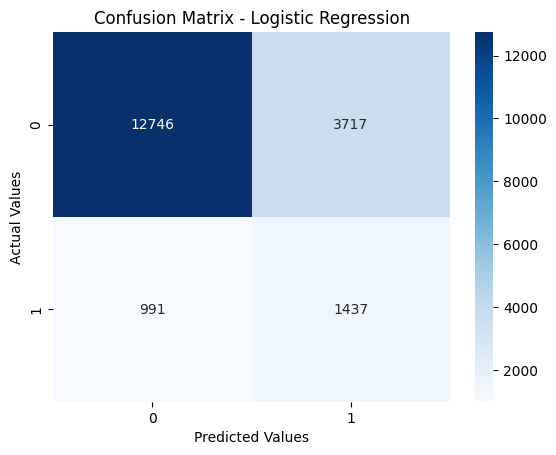

In [ ]:
con_mat = confusion_matrix(y_test, y_pred)

ax = sns.heatmap(
    con_mat,
    annot=True,
    cmap='Blues',
    fmt='d'
)

ax.set_title('Confusion Matrix - Logistic Regression')
ax.set_xlabel('Predicted Values')
ax.set_ylabel('Actual Values')

plt.show()

##SMOTE MODEL 2 - KNN

In [ ]:
knn_sm = KNeighborsClassifier(n_neighbors=5)

knn_sm.fit(X_train_sm, y_train_sm)

y_pred = knn_sm.predict(X_test)
y_prob = knn_sm.predict_proba(X_test)[:,1]

print("\nKNN Metrics:")
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1-Score :', f1_score(y_test, y_pred))
print('ROC-AUC  :', roc_auc_score(y_test, y_prob))



KNN Metrics:
Accuracy : 0.6752421788153089
Precision: 0.17949161334947258
Recall   : 0.42751235584843494
F1-Score : 0.2528315674095725
ROC-AUC  : 0.591277595078415


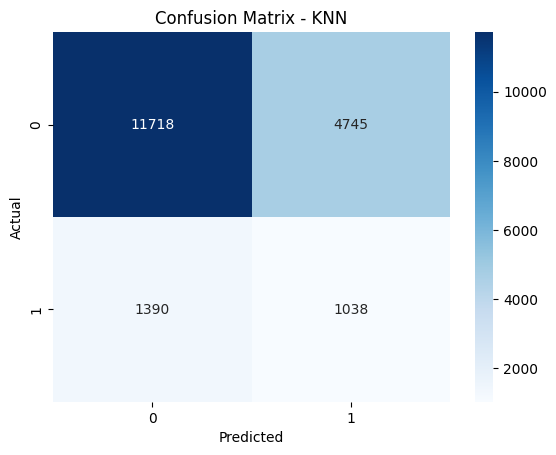

In [ ]:
con_mat = confusion_matrix(y_test, y_pred)

sns.heatmap(con_mat, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## SMOTE MODEL 3 - NAIVE BAYES

In [ ]:
nb_sm = GaussianNB()

nb_sm.fit(X_train_sm, y_train_sm)

y_pred = nb_sm.predict(X_test)
y_prob = nb_sm.predict_proba(X_test)[:,1]

print("\nNaive Bayes Metrics:")
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1-Score :', f1_score(y_test, y_pred))
print('ROC-AUC  :', roc_auc_score(y_test, y_prob))



Naive Bayes Metrics:
Accuracy : 0.8398708379651686
Precision: 0.3914940021810251
Recall   : 0.44357495881383857
F1-Score : 0.4159104074145588
ROC-AUC  : 0.723058238728331


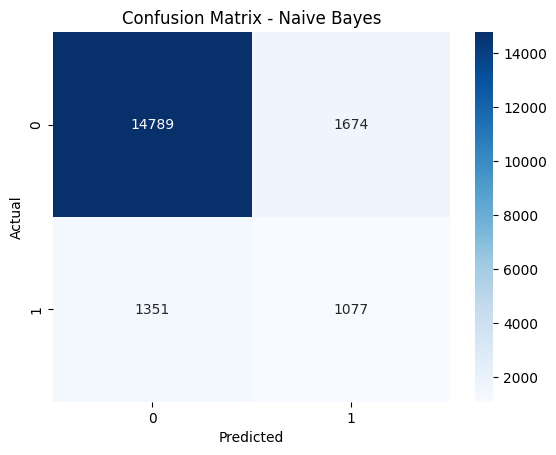

In [ ]:
con_mat = confusion_matrix(y_test, y_pred)

sns.heatmap(con_mat, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## SMOTE MODEL 4 - DECISION TREE

In [ ]:
dt_sm = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt_sm.fit(X_train_sm, y_train_sm)

y_pred = dt_sm.predict(X_test)
y_prob = dt_sm.predict_proba(X_test)[:,1]

print("\nDecision Tree Metrics:")
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1-Score :', f1_score(y_test, y_pred))
print('ROC-AUC  :', roc_auc_score(y_test, y_prob))


Decision Tree Metrics:
Accuracy : 0.8836482981313853
Precision: 0.5773889636608345
Recall   : 0.35337726523887975
F1-Score : 0.43842616249361266
ROC-AUC  : 0.7157374191700004


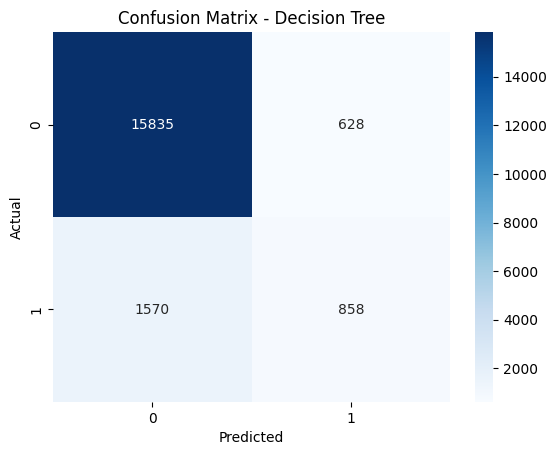

In [ ]:
con_mat = confusion_matrix(y_test, y_pred)

sns.heatmap(con_mat, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## SMOTE MODEL 5 - RANDOM FOREST

In [ ]:
rf_sm = RandomForestClassifier(
    random_state=42,
    n_estimators=100
)

rf_sm.fit(X_train_sm, y_train_sm)

y_pred = rf_sm.predict(X_test)
y_prob = rf_sm.predict_proba(X_test)[:,1]

print("\nRandom Forest Metrics:")
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1-Score :', f1_score(y_test, y_pred))
print('ROC-AUC  :', roc_auc_score(y_test, y_prob))


Random Forest Metrics:
Accuracy : 0.8886771478481816
Precision: 0.6272513703993735
Recall   : 0.3299011532125206
F1-Score : 0.43238866396761133
ROC-AUC  : 0.7424412648762273


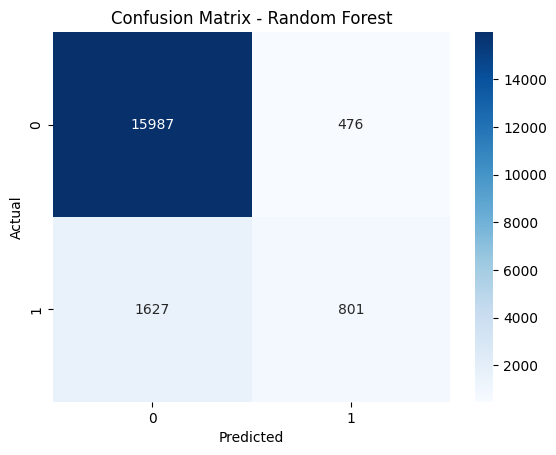

In [ ]:
con_mat = confusion_matrix(y_test, y_pred)

sns.heatmap(con_mat, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## SMOTE MODEL 6 - XGBOOST

In [ ]:
xgb_sm = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb_sm.fit(X_train_sm, y_train_sm)

y_pred = xgb_sm.predict(X_test)
y_prob = xgb_sm.predict_proba(X_test)[:,1]

print("\nXGBoost Metrics:")
print('Accuracy :', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall   :', recall_score(y_test, y_pred))
print('F1-Score :', f1_score(y_test, y_pred))
print('ROC-AUC  :', roc_auc_score(y_test, y_prob))


XGBoost Metrics:
Accuracy : 0.894235350166746
Precision: 0.7103718199608611
Recall   : 0.2990115321252059
F1-Score : 0.42086956521739133
ROC-AUC  : 0.7436059628895748


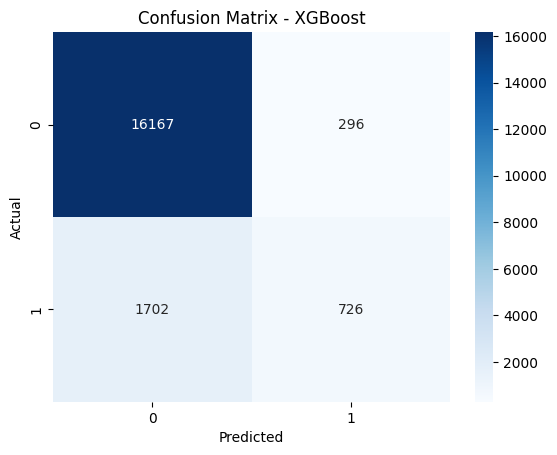

In [ ]:
con_mat = confusion_matrix(y_test, y_pred)

sns.heatmap(con_mat, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

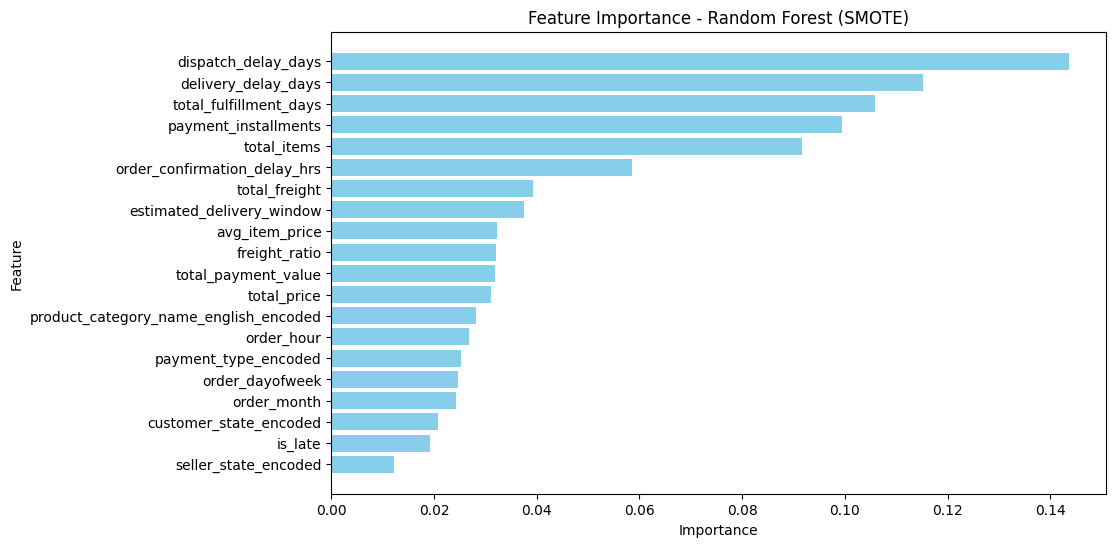

In [ ]:
importances = rf_sm.feature_importances_

feature_names = X_train.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color='skyblue'
)

plt.title('Feature Importance - Random Forest (SMOTE)')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.gca().invert_yaxis()

plt.show()

In [ ]:
print(importance_df.head(10))

                         Feature  Importance
12           dispatch_delay_days    0.143722
13           delivery_delay_days    0.115271
14        total_fulfillment_days    0.105851
4           payment_installments    0.099450
2                    total_items    0.091591
11  order_confirmation_delay_hrs    0.058627
1                  total_freight    0.039205
7      estimated_delivery_window    0.037483
6                 avg_item_price    0.032239
5                  freight_ratio    0.032009


##Model Comparison

In [ ]:
results = {
    'Logistic Regression': {
        'Accuracy': 0.7507, 'Precision': 0.2788,
        'Recall': 0.5918, 'F1': 0.3790, 'ROC-AUC': 0.7227
    },
    'KNN': {
        'Accuracy': 0.6752, 'Precision': 0.1795,
        'Recall': 0.4275, 'F1': 0.2528, 'ROC-AUC': 0.5913
    },
    'Naive Bayes': {
        'Accuracy': 0.8399, 'Precision': 0.3915,
        'Recall': 0.4436, 'F1': 0.4159, 'ROC-AUC': 0.7231
    },
    'Decision Tree': {
        'Accuracy': 0.8836, 'Precision': 0.5774,
        'Recall': 0.3534, 'F1': 0.4384, 'ROC-AUC': 0.7157
    },
    'Random Forest': {
        'Accuracy': 0.8887, 'Precision': 0.6273,
        'Recall': 0.3299, 'F1': 0.4324, 'ROC-AUC': 0.7424
    },
    'XGBoost': {
        'Accuracy': 0.8942, 'Precision': 0.7104,
        'Recall': 0.2990, 'F1': 0.4209, 'ROC-AUC': 0.7436
    }
}

comparison_df = pd.DataFrame(results).T.round(4)
print(comparison_df.to_string())

                     Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression    0.7507     0.2788  0.5918  0.3790   0.7227
KNN                    0.6752     0.1795  0.4275  0.2528   0.5913
Naive Bayes            0.8399     0.3915  0.4436  0.4159   0.7231
Decision Tree          0.8836     0.5774  0.3534  0.4384   0.7157
Random Forest          0.8887     0.6273  0.3299  0.4324   0.7424
XGBoost                0.8942     0.7104  0.2990  0.4209   0.7436


##Threshold Tuning on Logistic Regression

In [ ]:
# Predicted probabilities for class 1 (dissatisfied)
y_prob = lr_sm.predict_proba(X_test)[:, 1]

In [ ]:
print(f"{'Threshold':<10} {'Precision':<10} {'Recall':<10} {'F1':<10}")

for threshold in [0.50, 0.45, 0.40, 0.35, 0.30, 0.25]:

    y_pred = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(
        f"{threshold:<10}"
        f"{precision:.3f}     "
        f"{recall:.3f}     "
        f"{f1:.3f}"
    )

Threshold  Precision  Recall     F1        
0.5       0.279     0.592     0.379
0.45      0.242     0.640     0.351
0.4       0.209     0.699     0.321
0.35      0.180     0.766     0.291
0.3       0.157     0.841     0.265
0.25      0.142     0.908     0.245


##Threshold Tuning on Random Forest

In [ ]:
y_prob_rf = rf_sm.predict_proba(X_test)[:,1]

for threshold in [0.50, 0.45, 0.40, 0.35, 0.30]:

    y_pred_rf = (y_prob_rf >= threshold).astype(int)

    print(
        threshold,
        "Recall:", round(recall_score(y_test, y_pred_rf),3),
        "Precision:", round(precision_score(y_test, y_pred_rf),3),
        "F1:", round(f1_score(y_test, y_pred_rf),3)
    )

0.5 Recall: 0.334 Precision: 0.614 F1: 0.433
0.45 Recall: 0.368 Precision: 0.538 F1: 0.437
0.4 Recall: 0.408 Precision: 0.467 F1: 0.436
0.35 Recall: 0.461 Precision: 0.404 F1: 0.431
0.3 Recall: 0.516 Precision: 0.34 F1: 0.409


##Threshold Tuning on XGBoost

In [ ]:
y_prob_xgb = xgb_sm.predict_proba(X_test)[:,1]

for threshold in [0.50, 0.45, 0.40, 0.35, 0.30]:

    y_pred_xgb = (y_prob_xgb >= threshold).astype(int)

    print(
        threshold,
        "Recall:", round(recall_score(y_test, y_pred_xgb),3),
        "Precision:", round(precision_score(y_test, y_pred_xgb),3),
        "F1:", round(f1_score(y_test, y_pred_xgb),3)
    )

0.5 Recall: 0.299 Precision: 0.71 F1: 0.421
0.45 Recall: 0.313 Precision: 0.683 F1: 0.43
0.4 Recall: 0.33 Precision: 0.645 F1: 0.437
0.35 Recall: 0.354 Precision: 0.603 F1: 0.446
0.3 Recall: 0.387 Precision: 0.53 F1: 0.447


In [ ]:
#Since our project aims to identify dissatisfied customers early, Recall was prioritized

#Logistic Regression with threshold tuning achieved nearly 70% recall and was selected.

##Save

In [ ]:
import joblib

joblib.dump(
    lr_sm,
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/models/lr_smote.pkl'
)

joblib.dump(
    rf_sm,
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/models/rf_smote.pkl'
)

joblib.dump(
    xgb_sm,
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/models/xgb_smote.pkl'
)

print("Models saved")

Models saved
